# Full Dataset EDA and Cleaning Pipeline

This notebook rebuilds the EDA and machine-learning cleaning flow using `data/full_model_dataset.csv`, not the original February-only listings file.

The goal is to prepare a modeling-ready dataset for NYC Airbnb fair-price prediction while preserving temporal signals from January and February. No modeling is performed in this notebook.

## Step 1 - Load and Inspect

Load the merged dataset, inspect its dimensions, types, summary statistics, column names, and duplicate keys.

In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

DATA_PATH = "../data/full_model_dataset.csv"
PROCESSED_PATH = "../data/processed/clean_model_dataset.csv"

In [3]:
df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
df.info()

Shape: 34,563 rows x 42 columns
<class 'pandas.DataFrame'>
RangeIndex: 34563 entries, 0 to 34562
Data columns (total 42 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   id                                  34563 non-null  int64  
 1   name                                34561 non-null  str    
 2   host_id                             34563 non-null  int64  
 3   host_profile_id                     34201 non-null  float64
 4   host_name                           34563 non-null  str    
 5   neighbourhood_group                 34563 non-null  str    
 6   neighbourhood                       34563 non-null  str    
 7   latitude                            34563 non-null  float64
 8   longitude                           34563 non-null  float64
 9   room_type                           34563 non-null  str    
 10  price                               19855 non-null  float64
 11  price_jan           

In [3]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,34563.0,NaN,NaN,NaN,458932762021565184.0,544756371469155392.0,2539.0,21096822.0,50243139.0,963355980898713600.0,1544461035933787392.0
name,34561,32935,Water View King Bed Hotel Room,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,34563.0,NaN,NaN,NaN,172518078.738188,192931516.434831,1678.0,17775359.0,84766486.0,303156931.0,726475637.0
host_profile_id,34201.0,NaN,NaN,NaN,1465985618615744256.0,4407517800402136.0,1462506270716056832.0,1462841424952335104.0,1465456053387937536.0,1469130148498456832.0,1543009956275185408.0
host_name,34563,8104,Blueground,1176,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood_group,34563,5,Manhattan,15301,NaN,NaN,NaN,NaN,NaN,NaN,NaN
neighbourhood,34563,224,Bedford-Stuyvesant,2507,NaN,NaN,NaN,NaN,NaN,NaN,NaN
latitude,34563.0,NaN,NaN,NaN,40.728183,0.056425,40.50456,40.68803,40.72586,40.762094,40.91139
longitude,34563.0,NaN,NaN,NaN,-73.947167,0.05509,-74.251907,-73.983459,-73.954839,-73.927725,-73.711822
room_type,34563,4,Entire home/apt,18462,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
print("Column names:")
for col in df.columns:
    print(f"- {col}")

Column names:
- id
- name
- host_id
- host_profile_id
- host_name
- neighbourhood_group
- neighbourhood
- latitude
- longitude
- room_type
- price
- price_jan
- minimum_nights
- minimum_nights_jan
- number_of_reviews
- number_of_reviews_jan
- last_review
- last_review_jan
- reviews_per_month
- reviews_per_month_jan
- calculated_host_listings_count
- calculated_host_listings_count_jan
- availability_365
- availability_365_jan
- number_of_reviews_ltm
- number_of_reviews_ltm_jan
- license
- license_jan
- total_reviews_jan
- first_review_date_jan
- last_review_date_jan
- reviews_last_30d_jan
- reviews_last_90d_jan
- reviews_last_365d_jan
- days_since_last_review_jan
- total_reviews_feb
- first_review_date_feb
- last_review_date_feb
- reviews_last_30d_feb
- reviews_last_90d_feb
- reviews_last_365d_feb
- days_since_last_review_feb


In [5]:
inspection_summary = pd.Series({
    "duplicate_rows": df.duplicated().sum(),
    "duplicate_ids": df["id"].duplicated().sum(),
    "unique_ids": df["id"].nunique(),
    "row_count": len(df),
})

inspection_summary

duplicate_rows        0
duplicate_ids         0
unique_ids        34563
row_count         34563
dtype: int64

In [6]:
dtype_summary = (
    df.dtypes.astype(str)
    .rename("dtype")
    .reset_index()
    .rename(columns={"index": "column"})
)

dtype_summary

,column,dtype
0,id,int64
1,name,str
2,host_id,int64
3,host_profile_id,float64
4,host_name,str
5,neighbourhood_group,str
6,neighbourhood,str
7,latitude,float64
8,longitude,float64
9,room_type,str


## Step 2 - Missing Value Analysis

Compute missing-value percentages, identify high-missing and moderately missing columns, and assign an initial cleaning decision.

In [7]:
missing_summary = (
    pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_pct": df.isna().mean() * 100,
        "dtype": df.dtypes.astype(str),
    })
    .sort_values("missing_pct", ascending=False)
)

missing_summary

,missing_count,missing_pct,dtype
price_jan,34563,100.000000,float64
license_jan,29784,86.173075,str
license,29668,85.837456,str
price,14708,42.554176,float64
reviews_per_month,10568,30.576050,float64
last_review,10568,30.576050,str
first_review_date_feb,10405,30.104447,str
days_since_last_review_feb,10405,30.104447,float64
last_review_date_feb,10405,30.104447,str
reviews_per_month_jan,10118,29.274079,float64


In [8]:
high_missing_cols = missing_summary.query("missing_pct > 50").index.tolist()
moderate_missing_cols = missing_summary.query("10 <= missing_pct <= 50").index.tolist()

print("High missing columns (>50%):")
for col in high_missing_cols:
    print(f"- {col}: {missing_summary.loc[col, 'missing_pct']:.1f}%")

print()
print("Moderately missing columns (10-50%):")
for col in moderate_missing_cols:
    print(f"- {col}: {missing_summary.loc[col, 'missing_pct']:.1f}%")

High missing columns (>50%):
- price_jan: 100.0%
- license_jan: 86.2%
- license: 85.8%

Moderately missing columns (10-50%):
- price: 42.6%
- reviews_per_month: 30.6%
- last_review: 30.6%
- first_review_date_feb: 30.1%
- days_since_last_review_feb: 30.1%
- last_review_date_feb: 30.1%
- reviews_per_month_jan: 29.3%
- first_review_date_jan: 29.3%
- last_review_date_jan: 29.3%
- days_since_last_review_jan: 29.3%
- last_review_jan: 29.3%


In [9]:
missing_decisions = pd.DataFrame({
    "column": missing_summary.index,
    "missing_pct": missing_summary["missing_pct"].values,
    "decision": "keep / impute if selected",
})

missing_decisions.loc[missing_decisions["column"].isin(["price"]), "decision"] = "drop rows: target is required"
missing_decisions.loc[missing_decisions["column"].isin(["price_jan"]), "decision"] = "drop feature: January price is unavailable"
missing_decisions.loc[missing_decisions["column"].isin(["license", "license_jan"]), "decision"] = "convert to binary license signal, then drop raw text"
missing_decisions.loc[missing_decisions["column"].str.contains("review_date|last_review", regex=True), "decision"] = "use derived review features, then drop raw dates"
missing_decisions.loc[missing_decisions["column"].isin(["name", "host_name"]), "decision"] = "drop text identifier"
missing_decisions.loc[missing_decisions["column"].isin(["host_profile_id"]), "decision"] = "drop identifier"

missing_decisions.head(25)

,column,missing_pct,decision
0,price_jan,100.000000,drop feature: January price is unavailable
1,license_jan,86.173075,"convert to binary license signal, then drop ra..."
2,license,85.837456,"convert to binary license signal, then drop ra..."
3,price,42.554176,drop rows: target is required
4,reviews_per_month,30.576050,keep / impute if selected
5,last_review,30.576050,"use derived review features, then drop raw dates"
6,first_review_date_feb,30.104447,"use derived review features, then drop raw dates"
7,days_since_last_review_feb,30.104447,"use derived review features, then drop raw dates"
8,last_review_date_feb,30.104447,"use derived review features, then drop raw dates"
9,reviews_per_month_jan,29.274079,keep / impute if selected


## Step 3 - Target Variable Cleaning

Inspect `price`, create `log_price`, measure skew, and decide an outlier rule. The target is February/current listing price from the merged dataset.

In [10]:
df["price"] = pd.to_numeric(df["price"], errors="coerce")

price_summary = df["price"].describe(percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 0.995, 0.999])
price_skew = df["price"].skew()

print(price_summary)
print()
print(f"Raw price skew: {price_skew:.3f}")

count    19855.000000
mean       508.135029
std       3605.676342
min          9.000000
1%          36.000000
5%          46.000000
25%         90.000000
50%        155.000000
75%        267.000000
95%        602.300000
99%       2255.060000
99.5%    40000.000000
99.9%    50000.000000
max      50138.000000
Name: price, dtype: float64

Raw price skew: 12.753


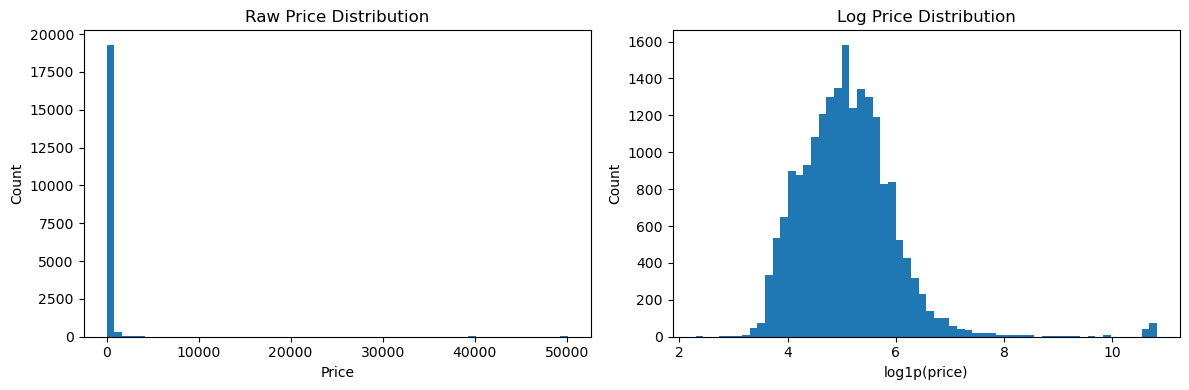

Log price skew: 1.746


In [11]:
target_eda = df.dropna(subset=["price"]).copy()
target_eda = target_eda[target_eda["price"] > 0].copy()
target_eda["log_price"] = np.log1p(target_eda["price"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(target_eda["price"], bins=60)
axes[0].set_title("Raw Price Distribution")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Count")

axes[1].hist(target_eda["log_price"], bins=60)
axes[1].set_title("Log Price Distribution")
axes[1].set_xlabel("log1p(price)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print(f"Log price skew: {target_eda['log_price'].skew():.3f}")

In [12]:
price_quantiles = target_eda["price"].quantile([0.95, 0.99, 0.995, 0.999])
price_cap = target_eda["price"].quantile(0.99)

print(price_quantiles)
print()
print(f"Chosen outlier rule: filter rows with price > 99th percentile (${price_cap:,.2f}).")

0.950      602.30
0.990     2255.06
0.995    40000.00
0.999    50000.00
Name: price, dtype: float64

Chosen outlier rule: filter rows with price > 99th percentile ($2,255.06).


## Step 4 - Feature Selection

Keep meaningful predictors and remove identifiers, text fields, raw date fields, raw license strings, and high-missing or leakage-prone columns. No categorical encoding is performed here.

In [13]:
raw_date_cols = [
    "last_review",
    "last_review_jan",
    "first_review_date_jan",
    "last_review_date_jan",
    "first_review_date_feb",
    "last_review_date_feb",
]

identifier_cols = ["id", "host_id", "host_profile_id"]
text_cols = ["name", "host_name"]
raw_license_cols = ["license", "license_jan"]
high_missing_or_unusable_cols = ["price_jan"]

columns_to_drop_after_feature_engineering = (
    identifier_cols
    + text_cols
    + raw_date_cols
    + raw_license_cols
    + high_missing_or_unusable_cols
)

pd.Series(columns_to_drop_after_feature_engineering, name="columns_to_drop")

0                        id
1                   host_id
2           host_profile_id
3                      name
4                 host_name
5               last_review
6           last_review_jan
7     first_review_date_jan
8      last_review_date_jan
9     first_review_date_feb
10     last_review_date_feb
11                  license
12              license_jan
13                price_jan
Name: columns_to_drop, dtype: str

## Step 5 - Feature Engineering

Create binary license/review signals, review momentum features, and simple log transforms for skewed numeric fields.

In [14]:
def add_features(data):
    out = data.copy()

    out["is_licensed"] = out["license"].notna().astype(int)
    out["was_licensed_jan"] = out["license_jan"].notna().astype(int)
    out["license_status_changed"] = (out["is_licensed"] != out["was_licensed_jan"]).astype(int)

    out["has_reviews"] = (out["number_of_reviews"].fillna(0) > 0).astype(int)
    out["has_reviews_jan"] = (out["number_of_reviews_jan"].fillna(0) > 0).astype(int)

    out["review_growth_30d"] = out["reviews_last_30d_feb"] - out["reviews_last_30d_jan"]
    out["review_growth_90d"] = out["reviews_last_90d_feb"] - out["reviews_last_90d_jan"]
    out["review_growth_365d"] = out["reviews_last_365d_feb"] - out["reviews_last_365d_jan"]
    out["total_review_growth"] = out["total_reviews_feb"] - out["total_reviews_jan"]

    out["availability_change"] = out["availability_365"] - out["availability_365_jan"]
    out["minimum_nights_change"] = out["minimum_nights"] - out["minimum_nights_jan"]
    out["host_listing_count_change"] = (
        out["calculated_host_listings_count"] - out["calculated_host_listings_count_jan"]
    )

    out["log_minimum_nights"] = np.log1p(out["minimum_nights"].clip(lower=0))
    out["log_host_listings"] = np.log1p(out["calculated_host_listings_count"].clip(lower=0))
    out["log_number_of_reviews"] = np.log1p(out["number_of_reviews"].clip(lower=0))
    out["log_total_reviews_feb"] = np.log1p(out["total_reviews_feb"].clip(lower=0))

    return out

feature_preview = add_features(df)
feature_preview[[
    "is_licensed",
    "has_reviews",
    "review_growth_30d",
    "review_growth_90d",
    "log_minimum_nights",
    "log_host_listings",
]].head()

,is_licensed,has_reviews,review_growth_30d,review_growth_90d,log_minimum_nights,log_host_listings
0,1,1,-1,0,1.098612,0.693147
1,0,1,0,0,3.433987,1.945910
2,0,0,0,0,3.433987,1.386294
3,0,0,0,0,3.433987,0.693147
4,0,1,0,0,3.433987,1.609438


## Step 6 - Categorical Handling

Identify categorical predictors and clean their category strings. Encoding is intentionally postponed until modeling.

In [15]:
categorical_cols = ["room_type", "neighbourhood", "neighbourhood_group"]

categorical_summary = pd.DataFrame({
    "column": categorical_cols,
    "unique_values": [df[col].nunique(dropna=False) for col in categorical_cols],
    "missing_pct": [df[col].isna().mean() * 100 for col in categorical_cols],
})

categorical_summary

,column,unique_values,missing_pct
0,room_type,4,0.0
1,neighbourhood,224,0.0
2,neighbourhood_group,5,0.0


In [16]:
for col in categorical_cols:
    print()
    print(col)
    print(df[col].astype("object").value_counts(dropna=False).head(20))


room_type
room_type
Entire home/apt    18462
Private room       15510
Hotel room           340
Shared room          251
Name: count, dtype: int64

neighbourhood
neighbourhood
Bedford-Stuyvesant    2507
Williamsburg          1967
Midtown               1921
Harlem                1611
Hell's Kitchen        1423
Bushwick              1416
Upper West Side       1404
Upper East Side       1325
Crown Heights         1081
East Village           894
Chelsea                799
East Harlem            639
Financial District     609
Lower East Side        583
Greenpoint             570
Astoria                527
Washington Heights     516
East Flatbush          489
West Village           455
Murray Hill            442
Name: count, dtype: int64

neighbourhood_group
neighbourhood_group
Manhattan        15301
Brooklyn         12743
Queens            5081
Bronx             1082
Staten Island      356
Name: count, dtype: int64


## Step 7 - Final Cleaning

Remove missing targets, apply the target outlier rule, impute numeric columns with medians, impute categorical columns with `Missing`, and enforce stable dtypes.

In [17]:
def clean_categories(data, categorical_columns):
    out = data.copy()
    for col in categorical_columns:
        out[col] = (
            out[col]
            .astype("object")
            .where(out[col].notna(), "Missing")
            .astype(str)
            .str.strip()
            .str.lower()
        )
        out.loc[out[col].isin(["", "nan", "none"]), col] = "missing"
    return out


def prepare_model_dataset(raw_df, price_upper_quantile=0.99):
    cleaned = raw_df.copy()

    numeric_candidates = [
        "price",
        "minimum_nights",
        "minimum_nights_jan",
        "number_of_reviews",
        "number_of_reviews_jan",
        "reviews_per_month",
        "reviews_per_month_jan",
        "calculated_host_listings_count",
        "calculated_host_listings_count_jan",
        "availability_365",
        "availability_365_jan",
        "number_of_reviews_ltm",
        "number_of_reviews_ltm_jan",
        "days_since_last_review_jan",
        "days_since_last_review_feb",
    ]
    for col in numeric_candidates:
        if col in cleaned.columns:
            cleaned[col] = pd.to_numeric(cleaned[col], errors="coerce")

    for col in raw_date_cols:
        if col in cleaned.columns:
            cleaned[col] = pd.to_datetime(cleaned[col], errors="coerce")

    rows_start = len(cleaned)
    cleaned = cleaned.dropna(subset=["price"]).copy()
    cleaned = cleaned[cleaned["price"] > 0].copy()

    price_cap_value = cleaned["price"].quantile(price_upper_quantile)
    cleaned = cleaned[cleaned["price"] <= price_cap_value].copy()
    cleaned["log_price"] = np.log1p(cleaned["price"])

    cleaned = add_features(cleaned)
    cleaned = clean_categories(cleaned, categorical_cols)

    drop_cols = [col for col in columns_to_drop_after_feature_engineering if col in cleaned.columns]
    cleaned = cleaned.drop(columns=drop_cols)

    numeric_cols = cleaned.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_model_cols = cleaned.select_dtypes(include=["object", "string"]).columns.tolist()

    for col in numeric_cols:
        median_value = cleaned[col].median()
        if pd.isna(median_value):
            median_value = 0
        cleaned[col] = cleaned[col].fillna(median_value)

    for col in categorical_model_cols:
        cleaned[col] = cleaned[col].fillna("missing").astype(str)

    cleaned = cleaned.reset_index(drop=True)

    summary = pd.Series({
        "starting_rows": rows_start,
        "rows_after_missing_target_and_positive_price": raw_df["price"].notna().sum(),
        "price_upper_quantile": price_upper_quantile,
        "price_cap": price_cap_value,
        "final_rows": len(cleaned),
        "final_columns": cleaned.shape[1],
        "numeric_columns": len(numeric_cols),
        "categorical_columns": len(categorical_model_cols),
    })

    return cleaned, summary

clean_model_df, cleaning_summary = prepare_model_dataset(df, price_upper_quantile=0.99)
cleaning_summary

starting_rows                                   34563.00
rows_after_missing_target_and_positive_price    19855.00
price_upper_quantile                                0.99
price_cap                                        2255.06
final_rows                                      19656.00
final_columns                                      45.00
numeric_columns                                    42.00
categorical_columns                                 3.00
dtype: float64

In [18]:
remaining_missing = clean_model_df.isna().sum()
remaining_missing[remaining_missing > 0]

Series([], dtype: int64)

In [19]:
print(f"Final shape: {clean_model_df.shape[0]:,} rows x {clean_model_df.shape[1]:,} columns")
print()
print("Final columns:")
for col in clean_model_df.columns:
    print(f"- {col}")

Final shape: 19,656 rows x 45 columns

Final columns:
- neighbourhood_group
- neighbourhood
- latitude
- longitude
- room_type
- price
- minimum_nights
- minimum_nights_jan
- number_of_reviews
- number_of_reviews_jan
- reviews_per_month
- reviews_per_month_jan
- calculated_host_listings_count
- calculated_host_listings_count_jan
- availability_365
- availability_365_jan
- number_of_reviews_ltm
- number_of_reviews_ltm_jan
- total_reviews_jan
- reviews_last_30d_jan
- reviews_last_90d_jan
- reviews_last_365d_jan
- days_since_last_review_jan
- total_reviews_feb
- reviews_last_30d_feb
- reviews_last_90d_feb
- reviews_last_365d_feb
- days_since_last_review_feb
- log_price
- is_licensed
- was_licensed_jan
- license_status_changed
- has_reviews
- has_reviews_jan
- review_growth_30d
- review_growth_90d
- review_growth_365d
- total_review_growth
- availability_change
- minimum_nights_change
- host_listing_count_change
- log_minimum_nights
- log_host_listings
- log_number_of_reviews
- log_total_r

In [20]:
clean_model_df.head()

,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,minimum_nights_jan,number_of_reviews,number_of_reviews_jan,reviews_per_month,reviews_per_month_jan,calculated_host_listings_count,calculated_host_listings_count_jan,availability_365,availability_365_jan,number_of_reviews_ltm,number_of_reviews_ltm_jan,total_reviews_jan,reviews_last_30d_jan,reviews_last_90d_jan,reviews_last_365d_jan,days_since_last_review_jan,total_reviews_feb,reviews_last_30d_feb,reviews_last_90d_feb,reviews_last_365d_feb,days_since_last_review_feb,log_price,is_licensed,was_licensed_jan,license_status_changed,has_reviews,has_reviews_jan,review_growth_30d,review_growth_90d,review_growth_365d,total_review_growth,availability_change,minimum_nights_change,host_listing_count_change,log_minimum_nights,log_host_listings,log_number_of_reviews,log_total_reviews_feb
0,staten island,eltingville,40.535470,-74.151350,private room,87.0,2,2.0,17,20,1.62,1.55,1,1,73,63,17,17,20,1,3,16,21.0,21,0,3,17,38.0,4.477337,1,1,0,1,1,-1,0,1,1,10,0.0,0,1.098612,0.693147,2.890372,3.091042
1,brooklyn,east flatbush,40.651855,-73.945082,private room,80.0,30,30.0,2,2,0.21,0.17,6,6,93,198,2,2,2,0,0,1,215.0,2,0,0,1,243.0,4.394449,0,0,0,1,1,0,0,0,0,-105,0.0,0,3.433987,1.945910,1.098612,1.098612
2,staten island,silver lake,40.620370,-74.101954,entire home/apt,99.0,30,30.0,0,0,0.44,0.41,3,3,201,55,0,0,0,0,0,0,162.0,0,0,0,0,180.0,4.605170,0,0,0,0,0,0,0,0,0,146,0.0,0,3.433987,1.386294,0.000000,0.000000
3,manhattan,west village,40.735566,-74.004233,entire home/apt,312.0,30,30.0,0,0,0.44,0.41,1,1,317,335,0,0,0,0,0,0,162.0,0,0,0,0,180.0,5.746203,0,0,0,0,0,0,0,0,0,-18,0.0,0,3.433987,0.693147,0.000000,0.000000
4,queens,jamaica,40.704184,-73.783945,entire home/apt,111.0,30,30.0,1,2,0.10,0.16,4,2,333,27,1,1,2,0,1,1,58.0,2,0,1,1,86.0,4.718499,0,0,0,1,1,0,0,0,0,306,0.0,2,3.433987,1.609438,0.693147,1.098612


## Step 8 - Save Processed Dataset

Save the modeling-ready dataset. This file keeps categorical columns unencoded so modeling notebooks can choose the right encoder inside a train/test or cross-validation pipeline.

In [21]:
os.makedirs("../data/processed", exist_ok=True)
clean_model_df.to_csv(PROCESSED_PATH, index=False)

print(f"Saved cleaned dataset to: {PROCESSED_PATH}")
print(f"Final shape: {clean_model_df.shape[0]:,} rows x {clean_model_df.shape[1]:,} columns")

Saved cleaned dataset to: ../data/processed/clean_model_dataset.csv
Final shape: 19,656 rows x 45 columns


In [22]:
transformations_applied = [
    "Loaded data/full_model_dataset.csv",
    "Checked shape, info, describe, duplicate rows, and duplicate listing ids",
    "Computed missing-value percentages and classified high/moderate missingness",
    "Converted price to numeric and removed rows with missing or non-positive price",
    "Filtered target outliers above the 99th percentile instead of modeling extreme $40k-$50k listings",
    "Created log_price = log1p(price)",
    "Created is_licensed, was_licensed_jan, license_status_changed, has_reviews, and has_reviews_jan",
    "Created review momentum features for 30d, 90d, 365d, and total reviews",
    "Created listing lag-change features for availability, minimum nights, and host listing count",
    "Created log_minimum_nights, log_host_listings, log_number_of_reviews, and log_total_reviews_feb",
    "Dropped identifiers, text fields, raw date fields, raw license strings, and unavailable price_jan",
    "Cleaned categorical string columns but did not encode them",
    "Filled numeric missing values with column medians",
    "Filled categorical missing values with 'missing'",
    "Saved data/processed/clean_model_dataset.csv",
]

for item in transformations_applied:
    print(f"- {item}")

- Loaded data/full_model_dataset.csv
- Checked shape, info, describe, duplicate rows, and duplicate listing ids
- Computed missing-value percentages and classified high/moderate missingness
- Converted price to numeric and removed rows with missing or non-positive price
- Filtered target outliers above the 99th percentile instead of modeling extreme $40k-$50k listings
- Created log_price = log1p(price)
- Created is_licensed, was_licensed_jan, license_status_changed, has_reviews, and has_reviews_jan
- Created review momentum features for 30d, 90d, 365d, and total reviews
- Created listing lag-change features for availability, minimum nights, and host listing count
- Created log_minimum_nights, log_host_listings, log_number_of_reviews, and log_total_reviews_feb
- Dropped identifiers, text fields, raw date fields, raw license strings, and unavailable price_jan
- Cleaned categorical string columns but did not encode them
- Filled numeric missing values with column medians
- Filled categori